# Overfitting, and the split that hides it

### A worked example on ocean dynamical regimes

**Who this is for.** Anyone comfortable with Python and NumPy who is fairly new
to machine learning, and who works with gridded data. No prior ML is assumed:
every term is explained where it first appears, and there is a glossary at the
end. If you already know what early stopping and cross-entropy are, skim to
section 6, which is where the ocean-specific part starts.

**The short version.** Most introductions to overfitting show a model that
memorises its training data, fix it with dropout, and stop there. Gridded ocean
data breaks that story, because **neighbouring grid cells are not independent
samples**. Split them at random and your "held-out" data is not held out in any
meaningful sense: you will measure a model that looks excellent and generalises
poorly, and none of the usual diagnostics will warn you.

**What we will do.**

1. Set up a real classification problem on global ocean data.
2. Train a first model and ask how we would know whether it is any good.
3. Make it overfit on purpose, and see which diagnostic catches it. Not
   accuracy.
4. Change *only how the data is split*, and watch the same model's apparent
   skill change completely.
5. Try the standard fixes, and find that the obvious one does not work and the
   unglamorous one does.

Every number below is measured in this notebook, not quoted from elsewhere. It
runs on a laptop CPU in a few minutes, offline.

## 1. The problem

The ocean does not circulate uniformly. In some regions the flow is set mainly
by the wind, in others by the shape of the sea floor, in others by friction or
by nonlinear eddy activity. Group the ocean by *which physical terms dominate
its vorticity balance* and you get a map of **dynamical regimes**: coherent
provinces, each behaving in a characteristic way.

Those regimes are useful but expensive. Working them out requires the full
vorticity budget, which you only have if your model stored every term. So the
practical question is whether a model can **predict the regime from variables
that are cheap and widely available**: the wind stress at the surface, the shape
of the sea floor, the mean sea-surface height, and latitude.

That is step 2 of **THOR** (Tracking global Heating with Ocean Regimes), and it
is the problem we borrow:

> Sonnewald, M. and Lguensat, R. (2021). *Revealing the impact of global heating
> on North Atlantic circulation using transparent machine learning.*
> Journal of Advances in Modeling Earth Systems **13**, e2021MS002496.
> [doi:10.1029/2021MS002496](https://doi.org/10.1029/2021MS002496) ·
> code: [maikejulie/DNN4Cli](https://github.com/maikejulie/DNN4Cli) (MIT)

The regime labels themselves come from an earlier, *unsupervised* step that
clustered the vorticity budget (Sonnewald et al. 2019). Because those labels
already exist, step 2 is a **supervised** problem, and that is the only kind we
deal with here.

> **Supervised classification**, in one sentence: you have many examples, each
> with some measured inputs and one correct answer from a fixed list of
> categories, and you want a function that maps new inputs to the right
> category.

Here, one example is **one ocean grid cell**. Its inputs are eight numbers
describing the local physics; its correct answer is one of six regime labels.
There are about 150,000 such cells.

## 2. Setup

The data ships with this notebook as a 1.8 MB `.npz`, so there is nothing to
download and no network needed. (`make_dataset.py` shows how that file was
built, if you want to audit the provenance.)

In [1]:
from pathlib import Path

DATA = Path("data/thor_step2_fields.npz")
assert DATA.exists(), f"{DATA} is missing - run: python make_dataset.py"
print(f"{DATA} ({DATA.stat().st_size / 1e6:.2f} MB)")

data/thor_step2_fields.npz (1.83 MB)


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import binary_dilation
from sklearn.preprocessing import StandardScaler

# Fixing the random seed makes this notebook reproducible: you should get the
# numbers printed below, not merely similar ones. Change it and everything
# shifts a little, which is itself worth knowing - a difference smaller than
# the seed-to-seed spread is not a real difference.
SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

# THOR's regime palette, kept so the maps below are recognisable from the paper
REGIME_CMAP = ListedColormap(
    ["royalblue", "cyan", "yellow", "orange", "magenta", "red"]
)
print("torch", torch.__version__)

torch 2.9.0


## 3. The data

Four fields, each a 360 x 720 grid covering the globe at half-degree
resolution, one value per cell.

| array | what it is |
| --- | --- |
| `curl` | wind stress curl: how much the wind twists the sea surface |
| `bathy` | bathymetry: depth of the sea floor |
| `ssh` | 20-year mean sea-surface height |
| `label` | the regime, 0 to 5, with `-1` over land |

From these we build the **eight inputs** THOR uses. Three are the fields
themselves, four are their horizontal gradients, and one is the Coriolis
parameter *f*, which captures how the effect of the Earth's rotation varies
with latitude.

Why gradients? Because dynamics often depends on how steeply something changes
in space rather than on its value. A flat abyssal plain and a steep continental
slope can sit at the same depth and behave completely differently.

Computing a gradient needs the physical size of a grid cell in metres. Cells are
the same size in degrees everywhere, but a degree of longitude shrinks towards
the poles, so the east-west spacing carries a cos(latitude) factor.

In [3]:
R_EARTH_DEG = 1.111774765625000e+05   # metres per degree, the constant THOR uses
OMEGA       = 7.2921e-5               # Earth's rotation rate, rad/s
DX_DEG      = 0.5                     # grid step in degrees

fields = np.load(DATA)
curl  = fields["curl"].astype("float64")
bathy = fields["bathy"].astype("float64")
ssh   = fields["ssh"].astype("float64")
label = fields["label"].astype("float64")
label[label == -1] = np.nan           # land is not a regime

n_lat, n_lon = curl.shape

# latitude of every cell, as a full 2-D field
lat = np.linspace(-90 + DX_DEG / 2, 90 - DX_DEG / 2, n_lat)[:, None]
lat = lat * np.ones((1, n_lon))

# physical size of one grid cell, in metres
cell_dy = np.gradient(lat, axis=0) * R_EARTH_DEG                  # north-south
cell_dx = np.abs(np.cos(np.deg2rad(lat))) * R_EARTH_DEG * DX_DEG  # east-west


def gradients(field):
    'Horizontal gradients of a 2-D field, in units per metre.'
    d_dx = np.gradient(field, axis=1) / cell_dx
    d_dy = np.gradient(field, axis=0) / cell_dy
    return d_dx, d_dy


dSdx, dSdy = gradients(ssh)
dHdx, dHdy = gradients(bathy)
coriolis   = 2 * OMEGA * np.sin(np.deg2rad(lat))

FEATURES = np.stack([curl, ssh, dSdx, dSdy, bathy, dHdx, dHdy, coriolis])
NAMES = ["wind stress curl", "SSH", "dSSH/dx", "dSSH/dy",
         "bathymetry", "dH/dx", "dH/dy", "Coriolis f"]

# THOR derives the east-west spacing with np.roll(lat, shift=-1) rather than
# from DX_DEG. That wraps at the north pole, so the single row at 89.75 deg N
# gets -179.5 deg instead of 0.5: a spacing 359x too large, with the wrong
# sign. We use the grid step directly. It changes 720 of ~149,600 cells, all
# of them in that one row.

print(f"{len(FEATURES)} inputs:")
for i, name in enumerate(NAMES):
    print(f"  {i}  {name}")

8 inputs:
  0  wind stress curl
  1  SSH
  2  dSSH/dx
  3  dSSH/dy
  4  bathymetry
  5  dH/dx
  6  dH/dy
  7  Coriolis f


Not every cell is usable. Land has no regime, some cells are missing an input,
and taking a gradient next to a coastline also produces a missing value, because
one of the neighbours it needs is land. A cell counts only where **every** input
and the label are present, which is the rule THOR applies.

In [4]:
# multiplying propagates NaN: if anything is missing here, the product is NaN
everything = np.stack([*FEATURES, label])
VALID = ~np.isnan(np.prod(everything, axis=0))

print(f"grid {n_lat} x {n_lon} = {VALID.size:,} cells")
print(f"usable ocean cells:    {VALID.sum():,}")

counts = np.bincount(label[VALID].astype(int), minlength=6)
print("\nhow common is each regime, as a percentage of usable cells:")
for k, pct in enumerate(100 * counts / counts.sum()):
    print(f"  regime {k}: {pct:5.1f}%")

grid 360 x 720 = 259,200 cells
usable ocean cells:    149,587

how common is each regime, as a percentage of usable cells:
  regime 0:  30.4%
  regime 1:  23.7%
  regime 2:  16.1%
  regime 3:   7.9%
  regime 4:   5.1%
  regime 5:  16.7%


Note that last block: the regimes are **imbalanced**. The commonest covers about
30% of the ocean, the rarest about 5%. That matters for reading accuracy later.

Before trusting any of this, two cheap checks that the grid is the right way up.
Row 0 should be Antarctic and therefore mostly land, and the Coriolis parameter
should be negative in the southern hemisphere and positive in the northern.
Getting a field upside down is an easy mistake, and a silent one.

In [5]:
print("land fraction by latitude band, south to north:")
for i in range(0, n_lat, 60):
    lo, hi = lat[i, 0], lat[min(i + 59, n_lat - 1), 0]
    print(f"  {lo:+6.1f}° to {hi:+6.1f}°   {1 - VALID[i:i+60].mean():.2f}")

print(f"\nCoriolis f: {coriolis[0,0]:+.2e} at the south edge, "
      f"{coriolis[-1,0]:+.2e} at the north edge")

land fraction by latitude band, south to north:
   -89.8° to  -60.2°   0.65
   -59.8° to  -30.2°   0.08
   -29.8° to   -0.2°   0.32
    +0.2° to  +29.8°   0.40
   +30.2° to  +59.8°   0.61
   +60.2° to  +89.8°   0.48

Coriolis f: -1.46e-04 at the south edge, +1.46e-04 at the north edge


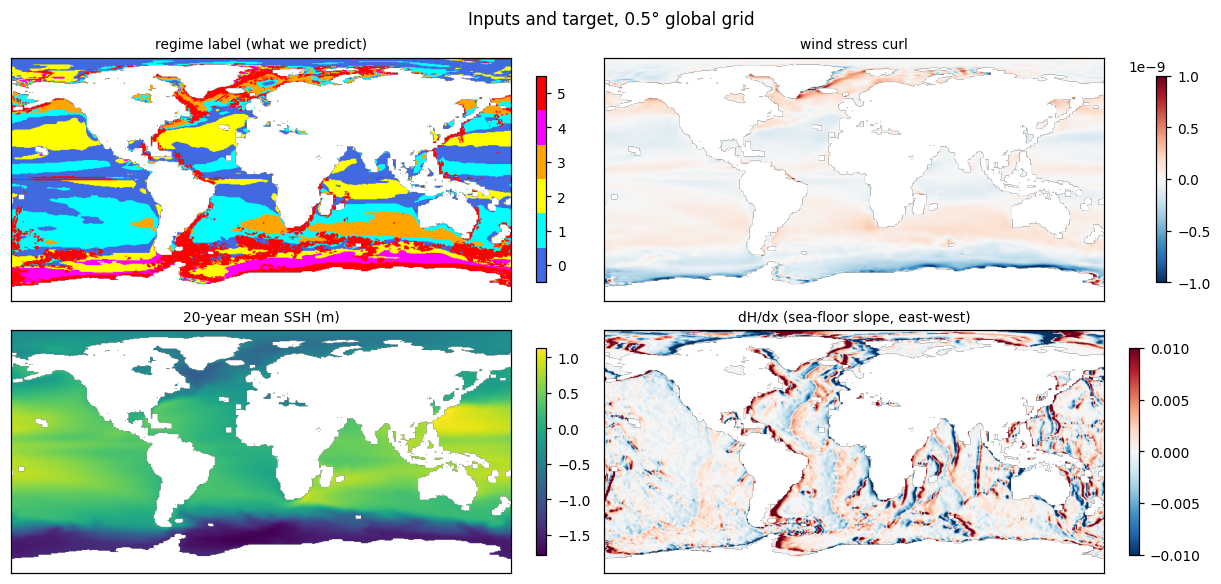

In [6]:
def show_map(ax, field, title, **kwargs):
    'Draw a 2-D field with north at the top, masked to usable cells.'
    masked = np.where(VALID, field, np.nan)
    image = ax.imshow(np.flipud(masked), aspect="auto", **kwargs)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    return image


fig, axes = plt.subplots(2, 2, figsize=(11, 5.2), constrained_layout=True)

im = show_map(axes[0, 0], label, "regime label (what we predict)",
              cmap=REGIME_CMAP, vmin=-0.5, vmax=5.5)
fig.colorbar(im, ax=axes[0, 0], ticks=range(6), shrink=0.85)

im = show_map(axes[0, 1], curl, "wind stress curl",
              cmap="RdBu_r", vmin=-1e-9, vmax=1e-9)
fig.colorbar(im, ax=axes[0, 1], shrink=0.85)

im = show_map(axes[1, 0], ssh, "20-year mean SSH (m)", cmap="viridis")
fig.colorbar(im, ax=axes[1, 0], shrink=0.85)

im = show_map(axes[1, 1], dHdx, "dH/dx (sea-floor slope, east-west)",
              cmap="RdBu_r", vmin=-1e-2, vmax=1e-2)
fig.colorbar(im, ax=axes[1, 1], shrink=0.85)

fig.suptitle("Inputs and target, 0.5° global grid", fontsize=11)
plt.show()

**What to look for.** Two things.

First, the inputs are clearly informative. The sea-floor slope picks out the
mid-ocean ridges, the wind stress curl is banded by latitude, and the mean SSH
shows the big subtropical gyres. A regime map built from physics ought to be
predictable from fields that look like these.

Second, and this is the one that matters later: **the regimes come in large
coherent patches, not scattered pixels.** Neighbouring cells almost always share
a label. Hold that thought until section 6.

## 4. A first model, and how to judge it

### What training means here

Our model is a **neural network**, which for our purposes is a flexible function
with a lot of adjustable numbers in it, called **parameters** or weights.
Training means showing it the inputs, comparing its answers with the correct
labels, and nudging the parameters to reduce the mistakes, over and over. One
full pass through the training data is an **epoch**.

The particular network is a **multilayer perceptron**: the eight inputs are
mixed into a layer of intermediate values, those are mixed into another layer,
and so on, until a final layer produces six numbers, one score per regime. We
use the shape THOR settled on, four hidden layers of sizes 24, 24, 16, 16.

### What we minimise

The model does not output a single guess. It outputs a **probability for each of
the six regimes**, summing to 1. We score those with **cross-entropy**, which is
small when the model puts high probability on the correct regime and grows
sharply when it is confidently wrong:

- true regime is 3, model gives it probability 0.5 → modest penalty
- true regime is 3, model gives it probability 0.9 → small penalty
- true regime is 3, model gives it probability 0.02 → **large** penalty

**Accuracy** — the fraction of cells labelled correctly — cannot see any of
this. It only asks whether the highest-probability regime happened to be right.
Two models with identical accuracy can differ enormously in how trustworthy
their probabilities are, and section 5 shows exactly that happening.

### Holding data back

If we judged the model on the same cells it trained on we would learn nothing,
because a flexible enough function can simply memorise them. So we **hold some
data back**, train on the rest, and score on the part held back.

*Which* cells to hold back is the subject of section 6, and it turns out to
matter more than anything else in this notebook.

In [7]:
class MLP(nn.Module):
    'A plain feed-forward network: n_in numbers in, one score per class out.'

    def __init__(self, n_in=8, hidden=(24, 24, 16, 16), n_out=6, dropout=0.0):
        super().__init__()
        layers = []
        width = n_in
        for h in hidden:
            layers.append(nn.Linear(width, h))   # mix the previous layer
            layers.append(nn.Tanh())             # bend it, so the whole thing is not just linear
            if dropout:
                layers.append(nn.Dropout(dropout))
            width = h
        layers.append(nn.Linear(width, n_out))   # six scores, one per regime
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def train(X_train, y_train, X_held, y_held, hidden=(24, 24, 16, 16),
          dropout=0.0, weight_decay=0.0, epochs=120, lr=1e-3, batch=128,
          seed=SEED):
    '''Train a model, recording loss and accuracy on both sets every epoch.

    Returns the fitted model and a history dict. Nothing about the held-out set
    ever influences training; it is only ever scored.
    '''
    torch.manual_seed(seed)
    model = MLP(X_train.shape[1], hidden, dropout=dropout)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    X_train = torch.as_tensor(X_train)
    y_train = torch.as_tensor(y_train)
    X_held = torch.as_tensor(X_held)
    y_held = torch.as_tensor(y_held)

    history = {k: [] for k in ("train_loss", "held_loss", "train_acc", "held_acc")}

    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(X_train))
        for start in range(0, len(X_train), batch):    # one epoch, in minibatches
            idx = order[start:start + batch]
            optimiser.zero_grad()
            loss_fn(model(X_train[idx]), y_train[idx]).backward()
            optimiser.step()

        model.eval()
        with torch.no_grad():
            for tag, X, y in (("train", X_train, y_train), ("held", X_held, y_held)):
                scores = model(X)
                history[f"{tag}_loss"].append(loss_fn(scores, y).item())
                history[f"{tag}_acc"].append((scores.argmax(1) == y).float().mean().item())

    return model, history


def cells_in(mask, n=None):
    'Feature matrix and labels for the cells in mask, optionally subsampled.'
    X = np.stack([field[mask] for field in FEATURES], axis=1).astype("float32")
    y = label[mask].astype("int64")
    if n is not None:
        keep = rng.choice(len(X), n, replace=False)
        X, y = X[keep], y[keep]
    return X, y


print(f"THOR-sized network: {count_parameters(MLP()):,} parameters")

THOR-sized network: 1,590 parameters


### The first split, and a baseline

Labelled ocean data is usually scarce, so let us act like it and train on
**3000 cells**, about 2% of the map. We hold out the **Atlantic**, which is what
THOR does.

Before training anything we need a number to beat. The simplest possible model
ignores the inputs entirely and always answers with the commonest regime. Any
real model has to beat that, and it is surprising how often a reported accuracy
turns out to sit close to this floor.

One more detail that is easy to get wrong. We **standardise** the inputs, shifting
and scaling each to mean 0 and standard deviation 1, because they have wildly
different units and a network trains badly when one input is 1e-9 and another is
1e3. The shift and scale must be computed from the **training cells only**.
Using all the data would let information about the held-out cells leak into
training. It is a small sin next to the one in section 6, but it is the same
kind of sin.

In [8]:
def longitude_band(col_from, col_to):
    'Usable cells whose grid column lies in [col_from, col_to).'
    band = np.zeros_like(VALID)
    band[:, col_from:col_to] = True
    return VALID & band


ATLANTIC = longitude_band(200, 400)        # roughly 80°W to 20°E
N_TRAIN = 3000

X_train, y_train = cells_in(VALID & ~ATLANTIC, n=N_TRAIN)
X_held, y_held = cells_in(ATLANTIC)

scaler = StandardScaler().fit(X_train)     # training cells only


def standardise(X):
    return scaler.transform(X).astype("float32")


print(f"training on {len(X_train):,} cells (subsampled from outside the Atlantic)")
print(f"held out:    {len(X_held):,} cells (the Atlantic)")

baseline = np.bincount(y_held).max() / len(y_held)
print(f"\nbaseline - always guess the commonest regime: {baseline:.3f}")

training on 3,000 cells (subsampled from outside the Atlantic)
held out:    40,328 cells (the Atlantic)

baseline - always guess the commonest regime: 0.254


## 5. Overfitting: when more training makes things worse

**Overfitting** is what happens when a model has enough freedom to memorise
quirks of its particular training examples instead of the pattern behind them.
Those quirks do not recur in new data, so performance on held-out data stops
improving and then degrades, even while performance on the training data keeps
getting better.

The classic recipe for causing it is a model with many parameters and not much
data. So let us compare two networks on the same 3000 cells: THOR's, and a
deliberately oversized one with four hidden layers of 256.

In [9]:
runs = {}
for tag, hidden in [("THOR-sized", (24, 24, 16, 16)),
                    ("oversized", (256,) * 4)]:
    n_par = count_parameters(MLP(8, hidden))
    _, runs[tag] = train(standardise(X_train), y_train,
                         standardise(X_held), y_held,
                         hidden=hidden, epochs=120)
    h = runs[tag]
    best = int(np.argmin(h["held_loss"]))
    print(f"{tag:12s} {n_par:>7,} parameters for {N_TRAIN:,} training cells")
    print(f"{'':12s} best held-out loss {h['held_loss'][best]:.3f} at epoch {best}, "
          f"then {h['held_loss'][-1]:.3f} by epoch 120 "
          f"({h['held_loss'][-1] - h['held_loss'][best]:+.3f})")
    print(f"{'':12s} held-out accuracy  {h['held_acc'][best]:.3f} at that epoch, "
          f"{h['held_acc'][-1]:.3f} at epoch 120\n")

THOR-sized     1,590 parameters for 3,000 training cells
             best held-out loss 0.525 at epoch 70, then 0.574 by epoch 120 (+0.049)
             held-out accuracy  0.794 at that epoch, 0.784 at epoch 120



oversized    201,222 parameters for 3,000 training cells
             best held-out loss 0.493 at epoch 11, then 1.234 by epoch 120 (+0.741)
             held-out accuracy  0.808 at that epoch, 0.767 at epoch 120



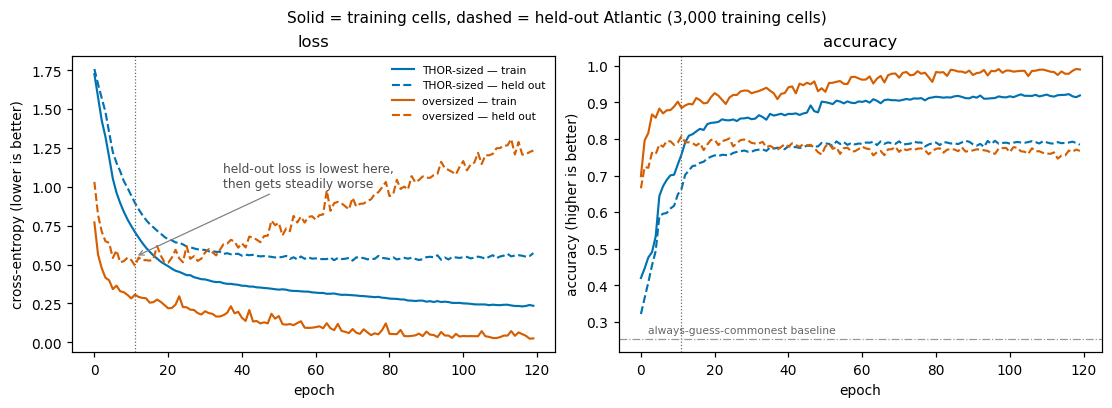

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
colour = {"THOR-sized": "#0072B2", "oversized": "#D55E00"}

for tag, h in runs.items():
    c = colour[tag]
    axes[0].plot(h["train_loss"], color=c, lw=1.4, label=f"{tag} — train")
    axes[0].plot(h["held_loss"], color=c, lw=1.4, ls="--", label=f"{tag} — held out")
    axes[1].plot(h["train_acc"], color=c, lw=1.4)
    axes[1].plot(h["held_acc"], color=c, lw=1.4, ls="--")

turn = int(np.argmin(runs["oversized"]["held_loss"]))
for ax in axes:
    ax.axvline(turn, color="0.4", lw=0.8, ls=":")
    ax.set_xlabel("epoch")

axes[0].annotate("held-out loss is lowest here,\nthen gets steadily worse",
                 xy=(turn, 0.55), xytext=(turn + 24, 1.0), fontsize=8, color="0.3",
                 arrowprops=dict(arrowstyle="->", color="0.5", lw=0.8))
axes[0].set_ylabel("cross-entropy (lower is better)")
axes[0].set_title("loss")
axes[1].axhline(baseline, color="0.6", lw=0.8, ls="-.")
axes[1].text(2, baseline + 0.015, "always-guess-commonest baseline",
             fontsize=7, color="0.4")
axes[1].set_ylabel("accuracy (higher is better)")
axes[1].set_title("accuracy")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Solid = training cells, dashed = held-out Atlantic "
             f"({N_TRAIN:,} training cells)", fontsize=10)
plt.show()

**What to look for.** In the left panel the oversized model does exactly what
the textbook promises. Its training loss keeps falling, because it is steadily
memorising 3000 cells. Its held-out loss bottoms out very early and then climbs
for the remaining hundred epochs. That divergence is overfitting.

**Now compare the two panels, which is the part most tutorials skip.** Over the
same hundred epochs the held-out *loss* rises by about 150%, while held-out
*accuracy* slips by only about four points. Both degrade, so accuracy is not
blind here — but it is far less sensitive. A four-point drift is easy to
dismiss as noise; a loss that more than doubles is not.

And the extra thing the loss is detecting is something accuracy structurally
cannot see: not *which* regime the model picks, but how sure it is when it picks
wrong. Rather than assert that, let us measure it.

In [11]:
# train the same oversized model to two different stopping points, and compare
big = (256,) * 4
model_early, _ = train(standardise(X_train), y_train, standardise(X_held), y_held,
                       hidden=big, epochs=turn + 1)
model_late, _ = train(standardise(X_train), y_train, standardise(X_held), y_held,
                      hidden=big, epochs=120)

with torch.no_grad():
    X = torch.as_tensor(standardise(X_held))
    for tag, model in (("stopped at the dip", model_early),
                       ("trained to epoch 120", model_late)):
        probs = torch.softmax(model(X), dim=1).numpy()
        wrong = probs.argmax(1) != y_held
        # probability given to the TRUE regime, on the cells it got wrong.
        # Averaging this over all cells would be misleading: the correct
        # predictions grow more confident too, and swamp the signal.
        p_true_wrong = probs[wrong][np.arange(wrong.sum()), y_held[wrong]].mean()
        print(f"{tag:22s} accuracy {1 - wrong.mean():.3f}   "
              f"confidence when wrong {probs.max(1)[wrong].mean():.3f}   "
              f"probability left on the true regime when wrong {p_true_wrong:.3f}")

stopped at the dip     accuracy 0.808   confidence when wrong 0.726   probability left on the true regime when wrong 0.211
trained to epoch 120   accuracy 0.767   confidence when wrong 0.896   probability left on the true regime when wrong 0.086


There it is. Accuracy falls by four points, which you might shrug at. But look
at the other two columns: when the fully-trained model is wrong, it is now
**much more confident about being wrong**, and the probability it leaves on the
correct regime has collapsed to a fraction of what it was.

That second number is the one to care about. Early in training, a wrong answer
still kept the truth as a plausible runner-up. By epoch 120 the truth has been
all but ruled out. The model has not become much worse at guessing; it has
become far worse at knowing what it does not know.

That matters as soon as you want anything from the model beyond its top choice:
an uncertainty estimate, a probability map, a threshold for flagging cases for
a human to check. All of those read the probabilities, and the probabilities are
what degraded.

> **Practical rule.** Monitor cross-entropy, or another proper scoring rule, not
> just accuracy. Accuracy is what you report; the loss is what warns you.

## 6. The split that hides it

Everything so far is standard and would look much the same on any dataset. This
section is about what makes gridded geophysical data different.

When you learn ML, the default way to make a held-out set is to shuffle the
examples and take a random slice; `train_test_split` does exactly this, and for
most datasets it is right. It assumes the examples are **independent**: that
knowing one tells you little about another.

Ocean grid cells badly violate that. Two cells 50 km apart share the same water
mass, the same weather and nearly the same depth, and as the regime map showed,
nearly always the same label. They are less like two independent observations
than like one observation written down twice.

So let us hold the model and the data fixed and change **only how the held-out
cells are chosen**:

- **random** — sample held-out cells uniformly from anywhere in the ocean;
- **geographic** — hold out the Atlantic, as we have been doing.

We will also measure *why* they differ, with a simple diagnostic: for each
held-out cell, is there a training cell among its eight immediate neighbours?

In [12]:
def random_split(n_train=None, frac_held=0.27):
    'Held-out cells sampled uniformly from the whole ocean.'
    idx = np.flatnonzero(VALID.ravel()).copy()
    rng.shuffle(idx)
    cut = int(len(idx) * frac_held)
    held_idx, train_idx = idx[:cut], idx[cut:]
    if n_train:
        train_idx = train_idx[:n_train]
    masks = []
    for chosen in (train_idx, held_idx):
        m = np.zeros(VALID.size, bool)
        m[chosen] = True
        masks.append(m.reshape(VALID.shape))
    return masks


def geographic_split(n_train=None):
    'Held-out cells are the Atlantic; training cells come from everywhere else.'
    m_train, m_held = VALID & ~ATLANTIC, VALID & ATLANTIC
    if n_train:
        idx = np.flatnonzero(m_train.ravel()).copy()
        rng.shuffle(idx)
        m = np.zeros(VALID.size, bool)
        m[idx[:n_train]] = True
        m_train = m.reshape(VALID.shape)
    return m_train, m_held


def fraction_touching(m_train, m_held):
    'Share of held-out cells with a training cell in their 8-neighbourhood.'
    neighbourhood = binary_dilation(m_train, np.ones((3, 3), bool))
    return (neighbourhood & m_held).sum() / m_held.sum()

In [13]:
header = (f"{'training set':>14} {'split':>12} {'train':>8} {'held out':>10} "
          f"{'gap':>8} {'held-out cells adjacent':>25}")
print(header)
print("-" * len(header))

for n_train, size_label in [(N_TRAIN, f"{N_TRAIN:,} cells"), (None, "all cells")]:
    for scheme, splitter in [("random", random_split), ("geographic", geographic_split)]:
        m_train, m_held = splitter(n_train)
        Xa, ya = cells_in(m_train)
        Xb, yb = cells_in(m_held)
        sc = StandardScaler().fit(Xa)
        _, h = train(sc.transform(Xa).astype("float32"), ya,
                     sc.transform(Xb).astype("float32"), yb,
                     hidden=(24, 24, 16, 16), epochs=80)
        gap = h["train_acc"][-1] - h["held_acc"][-1]
        print(f"{size_label:>14} {scheme:>12} {h['train_acc'][-1]:>8.3f} "
              f"{h['held_acc'][-1]:>10.3f} {gap:>+8.3f} "
              f"{100 * fraction_touching(m_train, m_held):>24.1f}%")

  training set        split    train   held out      gap   held-out cells adjacent
----------------------------------------------------------------------------------


   3,000 cells       random    0.906      0.877   +0.029                     14.5%


   3,000 cells   geographic    0.921      0.786   +0.135                      0.1%


     all cells       random    0.911      0.911   -0.000                     99.9%


     all cells   geographic    0.925      0.821   +0.105                      0.7%


**Read the last column first, because it explains all the others.**

With a random split over the full dataset, **99.9% of the held-out cells are
directly adjacent to a cell the model trained on.** At half-degree spacing those
neighbours are nearly the same patch of ocean. The model is not being asked to
generalise to new places at all; it is filling in gaps between points it has
already seen. The gap it reports is about zero, and in this run very slightly
negative, the held-out score landing a hair *above* the training score.

That is a perfectly accurate measurement of interpolation skill. It just is not
the question anyone is asking. The question is usually "will this work somewhere
I have no labels?", and to answer that you have to hold somewhere out.

Hold out the Atlantic and adjacency drops below 1%, only the cells right on the
basin's edge, and the gap jumps by an order of magnitude.

Notice too that shrinking the training set to 3000 cells narrows the difference
between the two schemes without closing it. Sparse sampling cuts adjacency to
about 15%, yet the random split still understates the gap several-fold. Spatial
correlation reaches well past the neighbouring cell.

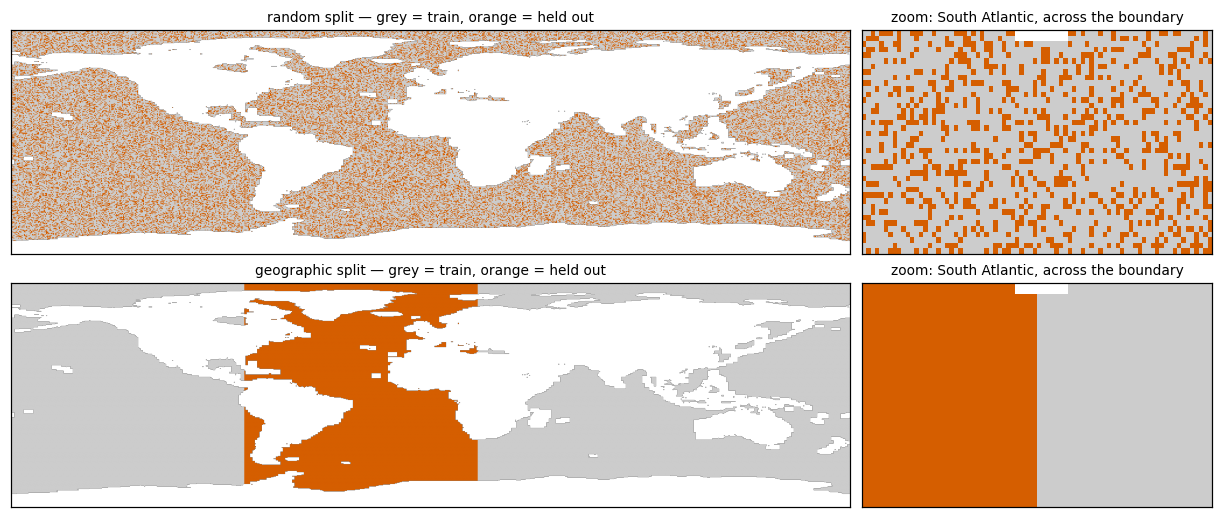

In [14]:
m_train_r, m_held_r = random_split(n_train=None)
m_train_g, m_held_g = geographic_split(n_train=None)

fig, axes = plt.subplots(2, 2, figsize=(11, 4.6), constrained_layout=True,
                         gridspec_kw={"width_ratios": [2.4, 1]})
ZOOM = (slice(70, 110), slice(360, 440))   # South Atlantic, straddling 20°E
split_cmap = ListedColormap(["#cccccc", "#D55E00"])

for row, (m_train, m_held, name) in enumerate([
        (m_train_r, m_held_r, "random split"),
        (m_train_g, m_held_g, "geographic split")]):
    canvas = np.full(VALID.shape, np.nan)
    canvas[m_train] = 0
    canvas[m_held] = 1
    axes[row, 0].imshow(np.flipud(canvas), cmap=split_cmap, aspect="auto",
                        vmin=-0.5, vmax=1.5)
    axes[row, 0].set_title(f"{name} — grey = train, orange = held out", fontsize=9)
    axes[row, 1].imshow(np.flipud(canvas[ZOOM]), cmap=split_cmap, aspect="auto",
                        vmin=-0.5, vmax=1.5, interpolation="nearest")
    axes[row, 1].set_title("zoom: South Atlantic, across the boundary", fontsize=9)
    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

The zoom is the whole argument in one picture. Both panels show the same small
window over the South Atlantic, crossing the edge of the held-out region at
20°E.

Under the random split every orange held-out cell is ringed by grey training
cells: that is the 99.9%. Under the geographic split the same window is cut
cleanly in two, and the model has to extrapolate across the line.

> **Practical rule.** For gridded data, hold out something with spatial extent:
> a basin, a region, tiles in a checkerboard, a time period. Not individual
> cells at random.

## 7. What actually helps

Section 5 suggests regularisation, section 6 says measure honestly. Putting the
two together exposes an awkward problem with what we did earlier: we chose the
stopping epoch by looking at the Atlantic, and then reported the Atlantic score.
That is leakage too, just subtler. The decision was made using the very data we
then used to report.

The fix is three separate regions:

| split | region | what it is for |
| --- | --- | --- |
| train | Indian + western Pacific | fitting the parameters |
| validation | eastern Pacific | deciding when to stop |
| test | Atlantic | scored once, at the very end |

And the three techniques we will compare:

- **Early stopping** — stop at the epoch where validation loss is lowest,
  instead of training for a fixed number of epochs.
- **Dropout** — during training, randomly ignore a fraction of the network's
  intermediate values at each step, so it cannot lean too hard on any one of
  them.
- **Weight decay** — penalise large parameters, which keeps the fitted function
  smoother.

Dropout and weight decay are the standard first answers to overfitting. Watch
what they actually do here.

In [15]:
TRAIN_REGION = longitude_band(400, 720)   # 20°E to 180°E  - Indian + west Pacific
VAL_REGION   = longitude_band(0, 200)     # 180°W to 80°W  - eastern Pacific
TEST_REGION  = longitude_band(200, 400)   # 80°W to 20°E   - Atlantic

for name, mask in [("train", TRAIN_REGION), ("val", VAL_REGION), ("test", TEST_REGION)]:
    c = np.bincount(label[mask].astype(int), minlength=6)
    print(f"{name:5s} {mask.sum():>7,} cells   regime %: {np.round(100 * c / c.sum(), 1)}")

train  57,283 cells   regime %: [29.6 20.9 13.5 11.9  6.2 18. ]
val    51,976 cells   regime %: [35.3 29.3 18.2  3.   4.4  9.7]
test   40,328 cells   regime %: [25.4 20.5 16.9  8.6  4.4 24.1]


Look at those three rows of percentages before going on. The regions do not
contain the same mix of regimes: regime 3 is 11.9% of the training region but
3.0% of the validation region, and regime 5 is 18.0% against 9.7%. We are about
to ask the model to work on an ocean composed differently from the one it
learned on. Keep that in mind when reading the results.

In [16]:
X_tr, y_tr = cells_in(TRAIN_REGION, n=N_TRAIN)
X_va, y_va = cells_in(VAL_REGION)
X_te, y_te = cells_in(TEST_REGION)

scaler3 = StandardScaler().fit(X_tr)


def prep(X):
    return scaler3.transform(X).astype("float32")


BIG = (256,) * 4
configs = [
    ("oversized, no regularisation",  BIG, 0.0, 0.0),
    ("oversized + dropout 0.3",       BIG, 0.3, 0.0),
    ("oversized + weight decay 1e-3", BIG, 0.0, 1e-3),
    ("oversized + both",              BIG, 0.3, 1e-3),
    ("THOR-sized, no regularisation", (24, 24, 16, 16), 0.0, 0.0),
]

results = []
for tag, hidden, drop, decay in configs:
    # pass 1: find the best epoch, using the validation region only
    _, h_val = train(prep(X_tr), y_tr, prep(X_va), y_va, hidden=hidden,
                     dropout=drop, weight_decay=decay, epochs=120)
    stop_at = int(np.argmin(h_val["held_loss"])) + 1

    # pass 2: retrain to exactly that epoch, then score the Atlantic once
    _, h_test = train(prep(X_tr), y_tr, prep(X_te), y_te, hidden=hidden,
                      dropout=drop, weight_decay=decay, epochs=stop_at)
    gap = h_test["train_acc"][-1] - h_test["held_acc"][-1]
    results.append(dict(tag=tag, stop=stop_at, train=h_test["train_acc"][-1],
                        test=h_test["held_acc"][-1], gap=gap))
    print(f"{tag:30s} stopped at epoch {stop_at:>3d}   "
          f"train {h_test['train_acc'][-1]:.3f}   Atlantic {h_test['held_acc'][-1]:.3f}   "
          f"gap {gap:+.3f}")

# for contrast, the same model with no early stopping at all
_, h_none = train(prep(X_tr), y_tr, prep(X_te), y_te, hidden=BIG, epochs=120)
gap_none = h_none["train_acc"][-1] - h_none["held_acc"][-1]
print(f"\n{'oversized, NO early stopping':30s} {'(ran all 120)':>21}   "
      f"train {h_none['train_acc'][-1]:.3f}   Atlantic {h_none['held_acc'][-1]:.3f}   "
      f"gap {gap_none:+.3f}")
print(f"{'':30s} {'':>21}   Atlantic cross-entropy "
      f"{min(h_none['held_loss']):.3f} at its best epoch "
      f"-> {h_none['held_loss'][-1]:.3f} at epoch 120")

oversized, no regularisation   stopped at epoch  19   train 0.907   Atlantic 0.816   gap +0.092


oversized + dropout 0.3        stopped at epoch  81   train 0.929   Atlantic 0.794   gap +0.136


oversized + weight decay 1e-3  stopped at epoch  47   train 0.914   Atlantic 0.799   gap +0.115


oversized + both               stopped at epoch 102   train 0.911   Atlantic 0.798   gap +0.114


THOR-sized, no regularisation  stopped at epoch 105   train 0.915   Atlantic 0.812   gap +0.103



oversized, NO early stopping           (ran all 120)   train 0.980   Atlantic 0.769   gap +0.211
                                                       Atlantic cross-entropy 0.503 at its best epoch -> 1.246 at epoch 120


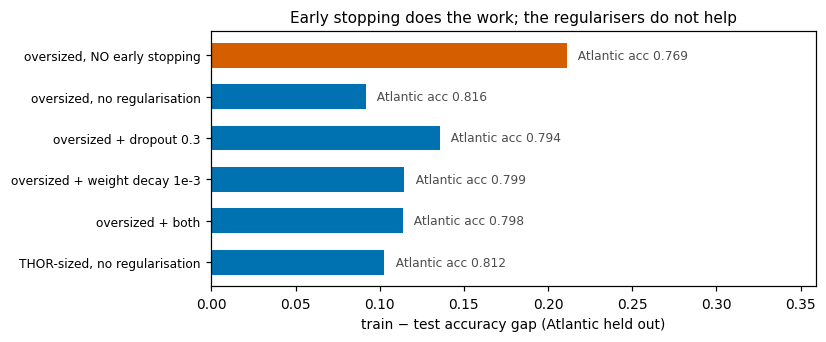

In [17]:
fig, ax = plt.subplots(figsize=(7.4, 3.0), constrained_layout=True)

tags = [r["tag"] for r in results][::-1] + ["oversized, NO early stopping"]
gaps = [r["gap"] for r in results][::-1] + [gap_none]
accs = [r["test"] for r in results][::-1] + [h_none["held_acc"][-1]]
colours = ["#0072B2"] * len(results) + ["#D55E00"]

y = np.arange(len(tags))
ax.barh(y, gaps, color=colours, height=0.6)
for i, (g, a) in enumerate(zip(gaps, accs)):
    ax.text(g + 0.002, i, f"  Atlantic acc {a:.3f}", va="center", fontsize=8, color="0.3")
ax.set_yticks(y)
ax.set_yticklabels(tags, fontsize=8)
ax.set_xlabel("train − test accuracy gap (Atlantic held out)")
ax.set_xlim(0, max(gaps) * 1.7)
ax.set_title("Early stopping does the work; the regularisers do not help", fontsize=10)
plt.show()

This is not the tidy result a tutorial would script, and it is the most useful
thing in the notebook.

**Early stopping does the real work.** Compare the orange bar with the one just
above it: stopping at the validation minimum instead of running all 120 epochs
lifts Atlantic accuracy by about five points and roughly halves the gap. Without
it, Atlantic cross-entropy more than doubles as training continues.

**Dropout and weight decay then make things slightly worse.** Dropout costs
about two points of Atlantic accuracy relative to no regularisation at all;
weight decay costs a little less. The reason is visible in the printout above:
both push the validation minimum much later, and the extra epochs buy fit to the
Indo-Pacific that does not transfer. Shrinking to the THOR-sized network does
not rescue it either.

**Why the remaining gap is not overfitting.** The model is not memorising the
Indian Ocean; we early-stopped precisely to stop that. It is being asked about
an ocean that is genuinely different. Recall those regime percentages, and that
the Atlantic contains dynamical situations the Indo-Pacific training region
barely covers. This is **distribution shift**: a data problem, not a training
problem, and no regulariser removes it.

Telling the two apart is the practical skill:

| symptom | diagnosis | what helps |
| --- | --- | --- |
| validation loss rises while training loss falls | overfitting | early stopping, less capacity, more data |
| a gap that survives every regulariser, with the validation minimum arriving early | distribution shift | labels from the target region; report the limit honestly |

Neither is visible at all if you split at random.

## 8. Takeaways

1. **Accuracy is an insensitive overfitting detector.** Held-out cross-entropy
   more than doubled while held-out accuracy slipped only four points, and what
   the loss was detecting — the model becoming confident in its wrong answers —
   is something accuracy cannot see at all. Monitor a proper scoring rule.
2. **Never split gridded ocean data at random.** With a random split, 99.9% of
   our held-out cells touched a training cell and the gap vanished completely,
   while holding out a basin exposed a gap of `+0.105`. Hold out regions, blocks
   or time periods, something with spatial extent.
3. **Early stopping needs its own region.** Choosing the stopping epoch on the
   set you then report is leakage. Use three separate areas.
4. **Distinguish overfitting from distribution shift.** They look identical in a
   single number and have completely different remedies.
5. **Fit preprocessing on the training split only.** The scaler here never sees
   a held-out cell.

### Things to try from here

- **Rotate the held-out basin.** The Atlantic is not special, and the spread
  across basins is itself a useful uncertainty estimate.
- **Spatial block cross-validation.** Instead of sacrificing a whole basin, tile
  the globe and hold out whole tiles in turn. You get an error bar and keep more
  of your data.
- **Drop the three SSH inputs and re-run.** Adding them lifts the random-split
  score from 0.890 to 0.911 but leaves the Atlantic at 0.821, a touch *below*
  the five-input 0.825. Better features improved the number a random split
  reports and did nothing for the one that matters: section 6's lesson arriving
  from an unexpected direction.
- **Change `SEED`** and see how much everything moves. Differences smaller than
  that are not differences.
- **Train THOR's 50-member ensemble** and check whether averaging narrows the
  geographic gap or merely stabilises it.

### Glossary

| term | meaning |
| --- | --- |
| example | one item the model learns from; here, one ocean grid cell |
| feature / input | one measured number describing an example; we use eight |
| label / target | the correct answer; here, one of six regimes |
| parameter / weight | an adjustable number inside the model |
| capacity | roughly, how many parameters, so how much the model *can* memorise |
| epoch | one full pass through the training data |
| minibatch | the small chunk of examples used for one parameter update |
| loss | the quantity training minimises; here, cross-entropy |
| cross-entropy | a loss that punishes confident wrong answers heavily |
| accuracy | fraction of examples given the right label |
| calibration | whether stated probabilities match real-world frequencies |
| overfitting | learning quirks of the training examples that do not generalise |
| regularisation | anything limiting a model's freedom, e.g. dropout, weight decay |
| early stopping | halting training at the best validation epoch |
| validation set | data used to make choices *about* training |
| test set | data touched once, to report a final number |
| leakage | test information influencing training or model choice |
| distribution shift | test data drawn from a genuinely different population |
| spatial autocorrelation | nearby locations resembling one another |

### References

- Sonnewald, M. and Lguensat, R. (2021). *Revealing the impact of global heating
  on North Atlantic circulation using transparent machine learning.* JAMES 13,
  e2021MS002496. [doi:10.1029/2021MS002496](https://doi.org/10.1029/2021MS002496)
- Sonnewald, M., Wunsch, C. and Heimbach, P. (2019). *Unsupervised learning
  reveals geography of global ocean dynamical regions.* Earth and Space Science
  6, 784-794. [doi:10.1029/2018EA000519](https://doi.org/10.1029/2018EA000519)
- Roberts, D. R. et al. (2017). *Cross-validation strategies for data with
  temporal, spatial, hierarchical, or phylogenetic structure.* Ecography 40,
  913-929. [doi:10.1111/ecog.02881](https://doi.org/10.1111/ecog.02881)

Input data from [maikejulie/DNN4Cli](https://github.com/maikejulie/DNN4Cli)
(MIT) and the ECCO v4 release 3 state estimate.